In [56]:
import xarray as xr
import os
import matplotlib.pyplot as plt
import numpy as np

In [131]:
mount_path = '/mnt/ronja/nci/'
sec_path = 'ismip6_2300/masks/'
grounding_line_path = 'ismip6_2300/UNN_Ua/hist/sftflf_AIS_UNN_Ua_hist.nc' # just some file to plot grounding lines
grid = '8'

save_path = 'ismip6_hackathon/masks'

In [28]:
sectors = xr.open_dataset(os.path.join(mount_path,sec_path, 'sectors_' + str(grid) + 'km.nc'))
gl = xr.open_dataset(os.path.join(mount_path,grounding_line_path)) 

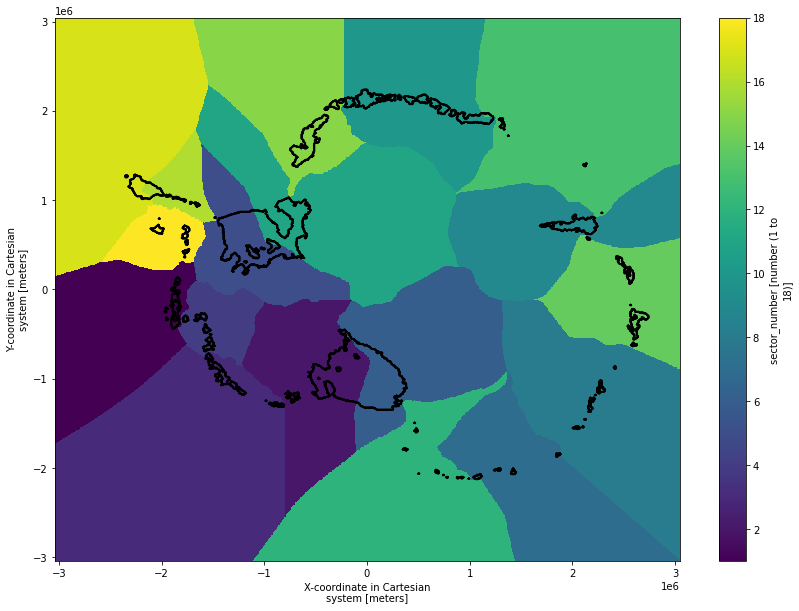

In [53]:
plt.figure(figsize=(14,10))

sectors.sectors.plot()

plt.contour(gl['x'],gl['y'],gl['sftflf'][-1,:].fillna(0) , colors='black')

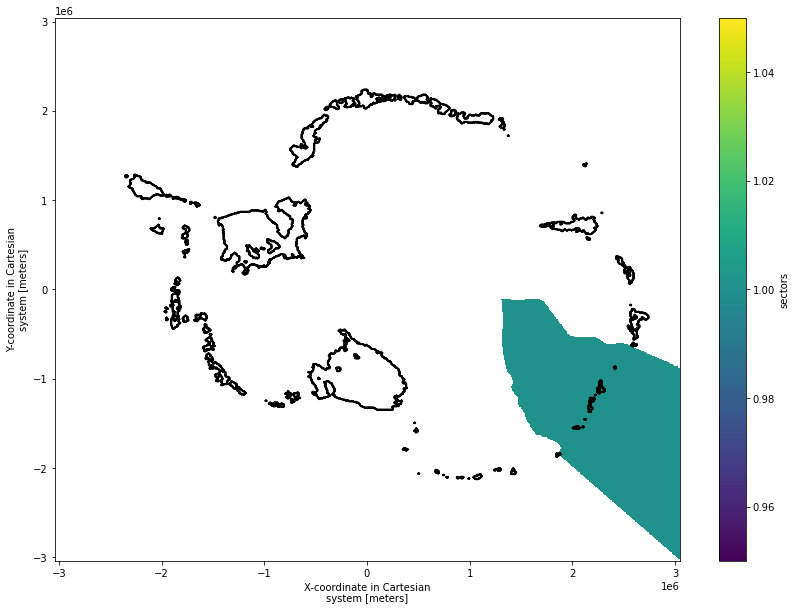

In [98]:
plt.figure(figsize=(14,10))

a = xr.where(sectors.sectors==8 ,1 , np.nan)
a.plot()
plt.contour(gl['x'],gl['y'],gl['sftflf'][-1,:].fillna(0) , colors='black')

In [83]:
names_of_sectors = ['', 'Bellingshausen Sea', 'Ross East', 'Getz', 'Amundsen Sea', 'Filchner-Ronne West', 
                   'Ross West', 'Wilkes Basin West',  'Totten, Moscow University', 'Amery', 'Dronning Maud Land', 
                    'Filchner-Ronne East', 'Wilkes Basin East', 'EAIS East', 'West IS', 'Brunt', 'AP South East', 
                    'AP Noth West', 'George VI', ]

# Regions of interest - Amundsen, Ross, FRIS

Note that we here combine and focus only on the regions: 

Amundsen Sea which was sector 4

Filchner-Ronne which is a combination of sectors 5 and 11

Ross Ice Shelf which is a combination of sectors 2 and 6

In [114]:
regionASE = sectors.sectors==4
regionFRIS = np.logical_or(sectors.sectors==5, sectors.sectors==11 )
regionRIS = np.logical_or(sectors.sectors==2, sectors.sectors== 6)



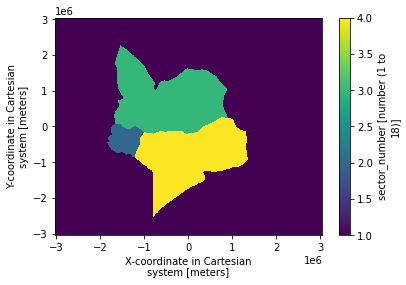

In [130]:
combined_mask = sectors.where(np.logical_or(sectors.sectors == 4, 
                              np.logical_or(sectors.sectors==5,
                              np.logical_or(sectors.sectors==11,             
                              np.logical_or(sectors.sectors==2,
                                            sectors.sectors==6 
                                           )))), other=1)

combined_mask = combined_mask.where(sectors.sectors!=4, other=2)
combined_mask = combined_mask.where(sectors.sectors!=5, other=3)
combined_mask = combined_mask.where(sectors.sectors!=11, other=3)
combined_mask = combined_mask.where(sectors.sectors!=2, other=4)
combined_mask = combined_mask.where(sectors.sectors!=6, other=4)


combined_mask.sectors.plot()


In [132]:
# Save this mask:

save_name = 'sectors_'+grid+'km_ASE_FRIS_RIS.nc'
combined_mask.to_netcdf(os.path.join(mount_path, save_path, save_name ))

# Modes of melting based - work in progress

In [97]:
mode1 = [2, 5, 6, 9, 11, 16,]
mode2 = [1, 3, 4, 8, 18, ] # What about Wilkes Land?
mode3 = [ 7, 10, 12, 13, 14, 15,  17] # others

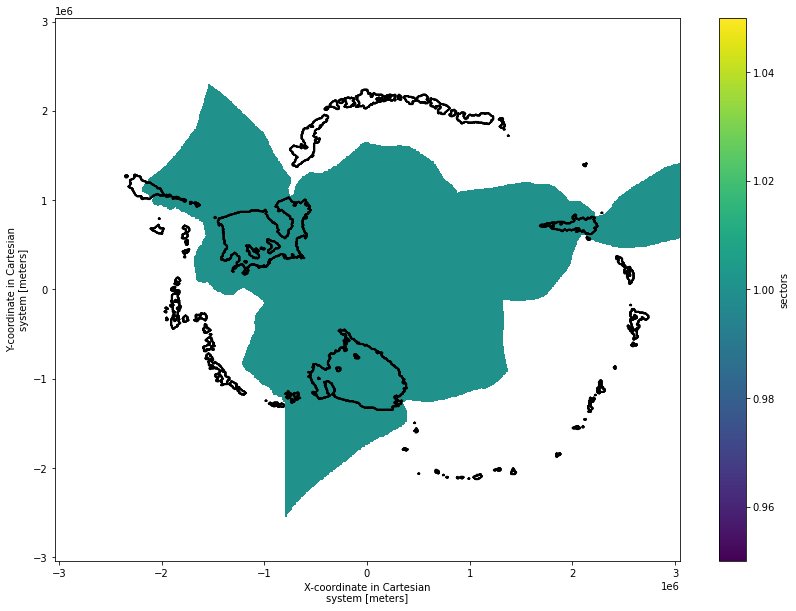

In [111]:
# MODE 1 mode1 = [2, 5, 6, 9, 11, 16,]
plt.figure(figsize=(14,10))

a = xr.where(np.logical_or(sectors.sectors==2, np.logical_or(sectors.sectors==5, np.logical_or(
            sectors.sectors==6, np.logical_or(sectors.sectors==9,np.logical_or(sectors.sectors==11,
                                                                              sectors.sectors==16) )))),1 , np.nan)
a.plot()
plt.contour(gl['x'],gl['y'],gl['sftflf'][-1,:].fillna(0) , colors='black')

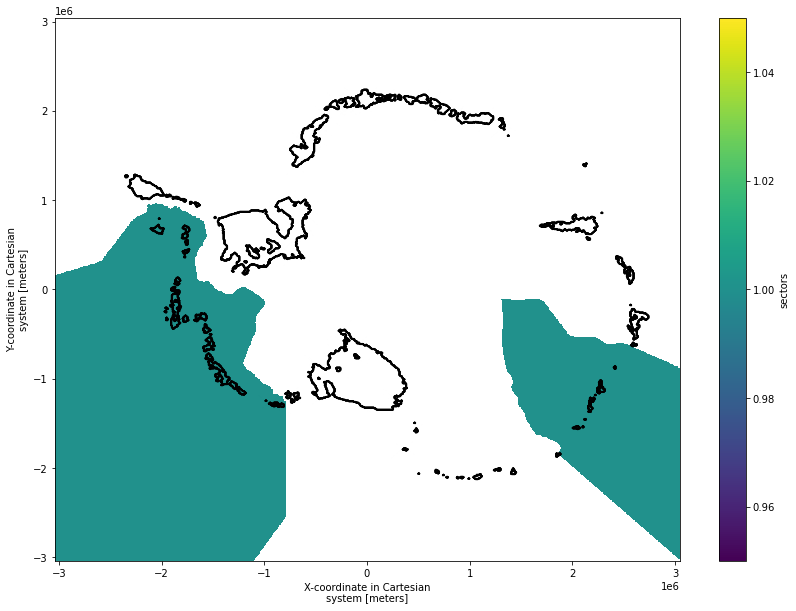

In [112]:
mode2 = [1, 3, 4, 8, 18, ] # What about Wilkes Land?

plt.figure(figsize=(14,10))

a = xr.where(np.logical_or(sectors.sectors==1, np.logical_or(sectors.sectors==3, np.logical_or(
            sectors.sectors==4, np.logical_or(sectors.sectors==8,sectors.sectors==18)))
                                                            ),1 , np.nan)
a.plot()
plt.contour(gl['x'],gl['y'],gl['sftflf'][-1,:].fillna(0) , colors='black')

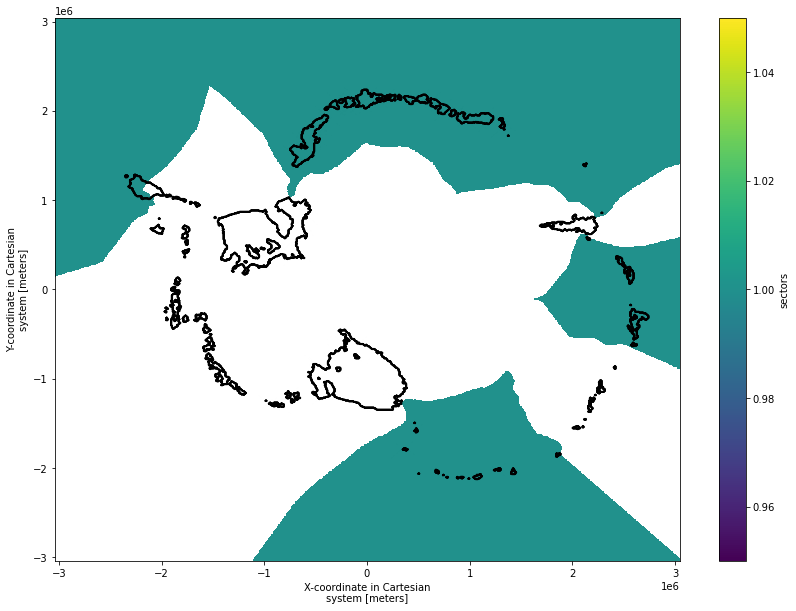

In [113]:
#mode3 = [ 7, 10, 12, 13, 14, 15,  17] # others

plt.figure(figsize=(14,10))

a = xr.where(np.logical_or(sectors.sectors==7, np.logical_or(sectors.sectors==10, np.logical_or(
            sectors.sectors==12, np.logical_or(sectors.sectors==13, np.logical_or(sectors.sectors==14,
            np.logical_or(sectors.sectors==15, np.logical_or(sectors.sectors==17, np.logical_or(
                sectors.sectors==17, sectors.sectors==17  ) ) ) ) )) ) ),1 , np.nan)
a.plot()
plt.contour(gl['x'],gl['y'],gl['sftflf'][-1,:].fillna(0) , colors='black')

In [ ]:
# Do we also want to save this?